# Section 6.1



## Example 6.1.2



The `OrdinaryDiffEq` package offers solvers for IVPs. Let's use it to define and solve the initial-value problem 

$$
u'=\sin[(u+t)^2], \quad t \in [0,4], \quad u(0)=-1.
$$

To create an initial-value problem for $u(t)$, we must supply a function that computes $u'$, an initial value for $u$, and the endpoints of the interval for $t$. The $t$ interval should be defined as `(a, b)`, where at least one of the values is a float.

```{tip}
Because many practical problems come with parameters that are fixed within an instance but varied from one instance to another, the syntax for IVPs includes a input argument `p` that stays fixed throughout the solution. Here we don't want to use that argument, but it must be in the definition for the solver to work.
```

In [12]:
f(u, p, t) = sin((t + u)^2)     # defines du/dt, must include p argument
u₀ = -1.0                       # initial value
tspan = (0.0, 4.0)              # t interval

(0.0, 4.0)

With the data above we define an IVP problem object and then solve it. Here we tell the solver to use the `Tsit5` method, which is a good first choice for most problems.

In [13]:
using OrdinaryDiffEq
ivp = ODEProblem(f, u₀, tspan)
sol = solve(ivp, Tsit5());

The resulting solution object can be shown using `plot`.

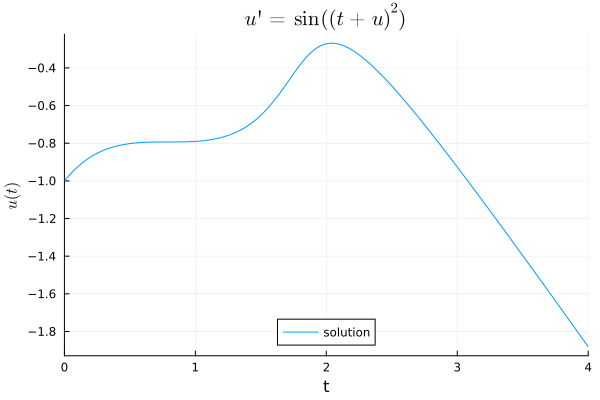

In [14]:
using Plots, LaTeXStrings
plot(sol;
    label="solution", legend=:bottom,
    xlabel="t",  ylabel=L"u(t)",
    title=L"u'=\sin((t+u)^2)")

The solution also acts like any callable function that can be evaluated at different values of $t$.

In [15]:
@show sol(1.0);

sol(1.0) = -0.7903205813665345


Under the hood, the solution object holds some information about how the values and plot are produced:

In [16]:
[sol.t sol.u]

15×2 Matrix{Float64}:
 0.0        -1.0
 0.0867807  -0.93483
 0.241035   -0.856617
 0.464665   -0.805668
 0.696832   -0.793614
 1.00862    -0.789925
 1.37461    -0.718601
 1.70407    -0.476837
 1.93572    -0.29033
 2.17184    -0.294994
 2.4843     -0.483948
 2.69425    -0.654121
 3.27049    -1.1783
 3.62534    -1.51729
 4.0        -1.88086

The solver initially finds approximate values of the solution (second column above) at some automatically chosen times (first column above). To compute the solution at other times, the object performs an interpolation on those values. This chapter is about how the discrete $t$ and $u$ values are computed. For now, just note how we can extract them from the solution object.

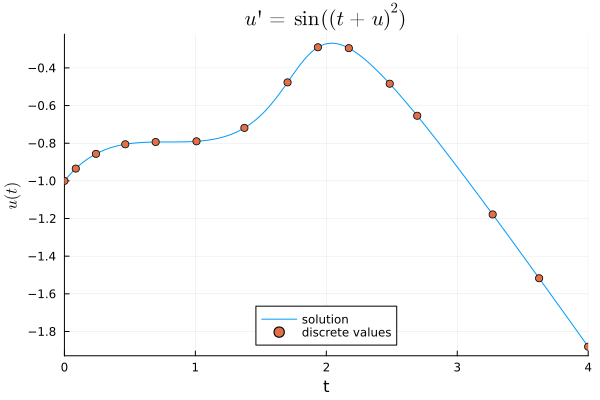

In [17]:
scatter!(sol.t, sol.u, label="discrete values")

## Example 6.1.3

The equation $u'=(u+t)^2$ gives us some trouble.

In [18]:
using OrdinaryDiffEq
f(u, p, t) = (t + u)^2
ivp = ODEProblem(f, 1.0, (0.0, 1.0))
sol = solve(ivp, Tsit5());

┌ Warning: Verbosity toggle: dt_epsilon 
│  At t= 0.7853839417697202, dt was forced below floating point epsilon 1.1102230246251565e-16. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64.
└ @ SciMLBase /Users/driscoll/.julia/packages/SciMLBase/rOg8U/src/integrator_interface.jl:736


The warning message we received can mean that there is a bug in the formulation of the problem. But if everything has been done correctly, it suggests that the solution may not exist past the indicated time. This is a possibility in nonlinear ODEs.

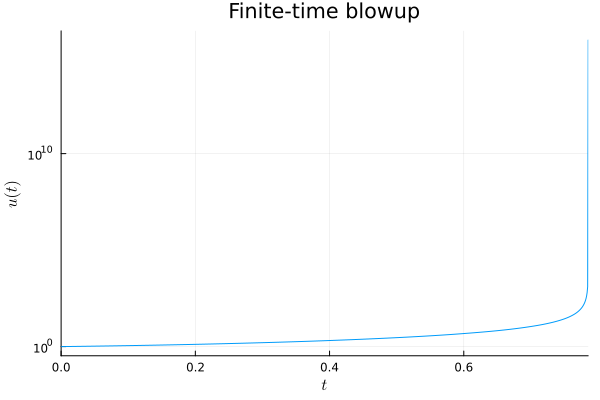

In [19]:
using Plots, LaTeXStrings
plot(sol, label="";
    xlabel=L"t",  yaxis=(:log10, L"u(t)"),
    title="Finite-time blowup")

## Example 6.1.5

Consider the ODEs $u'=u$ and $u'=-u$. In each case we compute $\partial f/\partial u = \pm 1$, so the condition number bound from @theorem-depIC is $e^{b-a}$ in both problems. However, they behave quite differently. In the case of exponential growth, $u'=u$, the bound is the actual condition number.

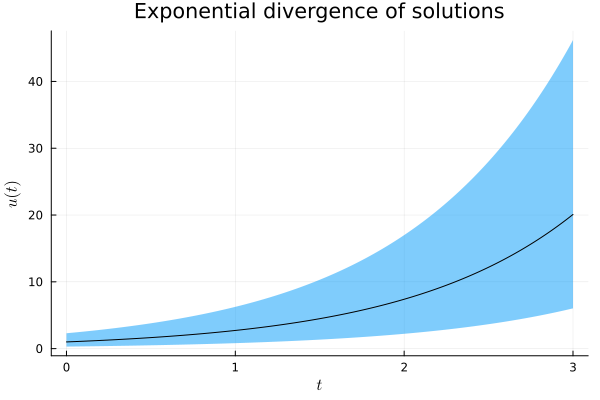

In [20]:
using Plots, LaTeXStrings
t = range(0, 3, length=800)
u = @. exp(t) * 1
lower, upper = @. exp(t) * 0.7, @. exp(t) * 1.3
plot(t, u;
    l=:black, ribbon=(lower, upper),
    leg=:none,  xlabel=L"t",  ylabel=L"u(t)",
    title="Exponential divergence of solutions")

But with $u'=-u$, solutions actually get closer together with time.

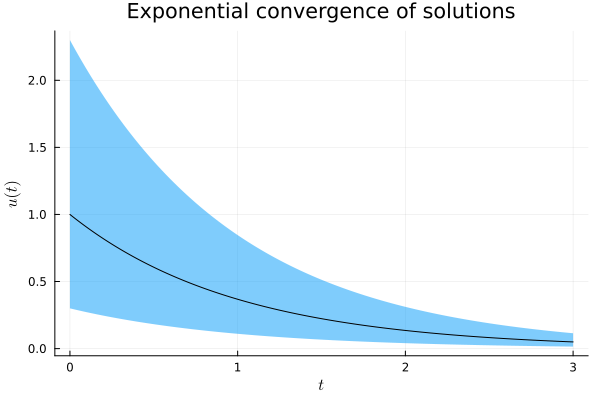

In [21]:
u = @. exp(-t) * 1
lower, upper = @. exp(-t) * 0.7, @. exp(-t) * 1.3
plot(t, u;
    l=:black,  ribbon=(lower, upper),
    leg=:none,  xlabel=L"t",  ylabel=L"u(t)",
    title="Exponential convergence of solutions")

In this case the actual condition number is one, because the initial difference between solutions is the largest over all time. Hence the exponentially growing bound $e^{b-a}$ is a gross overestimate.